# **Découverte des données**

In [1088]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss, accuracy_score, classification_report

print("- Numpy version:", np.__version__)
print("- matplotlib version :", matplotlib.__version__)
print("- Pandas version:", pd.__version__)

df = pd.read_csv('./train_data_accidents.csv')

- Numpy version: 2.0.2
- matplotlib version : 3.10.0
- Pandas version: 2.2.2


In [1089]:
print(df.columns)

Index(['place', 'catu', 'sexe', 'trajet', 'secu1', 'secu2', 'secu3', 'locp',
       'catv', 'an_nais', 'mois', 'occutc', 'obs', 'obsm', 'choc', 'manv',
       'lum', 'agg', 'int', 'atm', 'col', 'catr', 'circ', 'vosp', 'prof',
       'plan', 'surf', 'infra', 'situ', 'lat', 'long', 'hrmn', 'jour', 'grav'],
      dtype='object')


In [1090]:
df.drop(df.index[df['grav'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['sexe'] == -1], axis = 0, inplace = True)
df.drop(df.index[df['place'] == -1], axis = 0, inplace = True)

In [1091]:
groupes_catv = {
    1: [1, 50, 60, 80], #vélos, hoverboard
    2: [2, 30, 4, 5, 6, 31, 32, 33, 34, 41, 42, 43, 35, 36], #les trucs de motos là
    4: [3, 7, 8, 9, 10, 11, 12], #Véhicules légers
    5: [13, 14, 15, 16, 17, 18, 19, 37, 38, 39, 40], #Gros poids lourd
    6: [20, 21, 0, 99] #Autres
}

for key, values in groupes_catv.items():
    df["catv"].replace(values, key, inplace=True)


groupes_place = {
    2 : [2, 6],
    3 : [7, 8, 9],
    4 : [3, 4, 5]
}
for key, values in groupes_place.items():
    df["place"].replace(values, key, inplace=True)


groupes_undefined = {
    0 : [-1, 0]
}
for key, values in groupes_undefined.items():
    df["trajet"].replace(values, key, inplace=True)
    df["obs"].replace(values, key, inplace=True)
    df['choc'].replace(values, key, inplace=True)

groupes_obs = {
    3 : [3, 4, 5]
}
for key, values in groupes_obs.items():
    df["obs"].replace(values, key, inplace=True)


groupes_obsm = {
    2 : [2, 4],
    5 : [5, 6]
}
for key, values in groupes_obsm.items():
  df["obsm"].replace(values, key, inplace=True)

groupe_choc = {
    1 : [1, 2, 3],
    4 : [4, 5, 6]
}
for key, values in groupe_choc.items():
  df["choc"].replace(values, key, inplace=True)

groupe_choc = {
    1 : [1, 2, 3],
    4 : [4, 5, 6]
}
for key, values in groupe_choc.items():
  df["choc"].replace(values, key, inplace=True)

groupes_manv = {
    11 : [11, 13, 15, 17],
    12 : [12, 14, 16, 18]
}
for key, values in groupes_manv.items():
  df["manv"].replace(values, key, inplace=True)

groupes_catr = {
    5 : [5, 6, 9]
}
for key, values in groupes_catr.items():
  df["catr"].replace(values, key, inplace=True)

groupes_surf = {
    3 : [3, 4, 5, 6, 7, 8, 9]
}
for key, values in groupes_surf.items():
  df["surf"].replace(values, key, inplace=True)

groupes_infra = {
    9 : [4, 6, 7, 8, 9]
}
for key, values in groupes_infra.items():
  df["infra"].replace(values, key, inplace=True)

/tmp/ipykernel_243/99297527.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["catv"].replace(values, key, inplace=True)
/tmp/ipykernel_243/99297527.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using '

# **Parsing**

In [1092]:
df['heure'] = df['hrmn'].str.split(':').str[0]

In [1093]:
df = df.dropna(subset=['an_nais'])
df['age'] = 2021 - df['an_nais']

# **Regroupement**

In [1094]:
df['is_protected'] = df[['secu1', 'secu2', 'secu3']].isin([1, 2, 3, 5, 6, 7]).any(axis=1).astype(int)
df.drop(columns=['jour', 'occutc', 'lat', 'long', 'hrmn', 'an_nais', 'secu1','secu2', 'secu3', 'vosp'], inplace=True)

On constate tout d'abord que certaines données sont inutilisables à cause de NaN à certains endroits

# **Nettoyage des données (suppression des NaN, données non renseignées etc.)**

In [1095]:
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == -1)], axis = 0, inplace = True)
df.drop(df.index[(df['obsm'] == 1) & (df['locp'] == 0)], axis = 0, inplace = True)
df.drop(df.index[(df['catv'] == -1)], axis = 0, inplace = True)

print(df.count())
print(df.loc[df['infra'] == 7].count())

place           186772
catu            186772
sexe            186772
trajet          186772
locp            186772
catv            186772
mois            186772
obs             186772
obsm            186772
choc            186772
manv            186772
lum             186772
agg             186772
int             186772
atm             186772
col             186772
catr            186772
circ            186772
prof            186772
plan            186772
surf            186772
infra           186772
situ            186772
grav            186772
heure           186772
age             186772
is_protected    186772
dtype: int64
place           0
catu            0
sexe            0
trajet          0
locp            0
catv            0
mois            0
obs             0
obsm            0
choc            0
manv            0
lum             0
agg             0
int             0
atm             0
col             0
catr            0
circ            0
prof            0
plan            0
surf  

In [1096]:
print(df.columns)

Index(['place', 'catu', 'sexe', 'trajet', 'locp', 'catv', 'mois', 'obs',
       'obsm', 'choc', 'manv', 'lum', 'agg', 'int', 'atm', 'col', 'catr',
       'circ', 'prof', 'plan', 'surf', 'infra', 'situ', 'grav', 'heure', 'age',
       'is_protected'],
      dtype='object')


<Axes: >

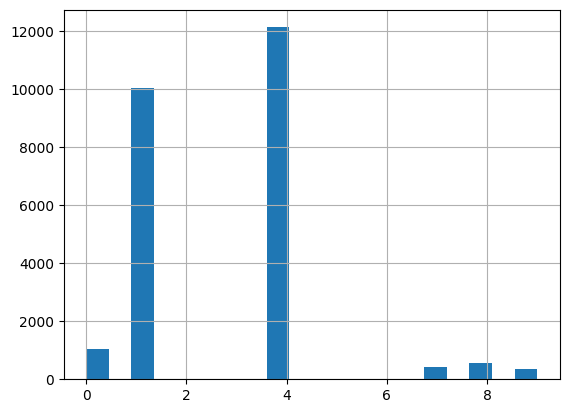

In [1097]:
df['choc'].loc[(df['col'] == 4)].hist(bins=20)

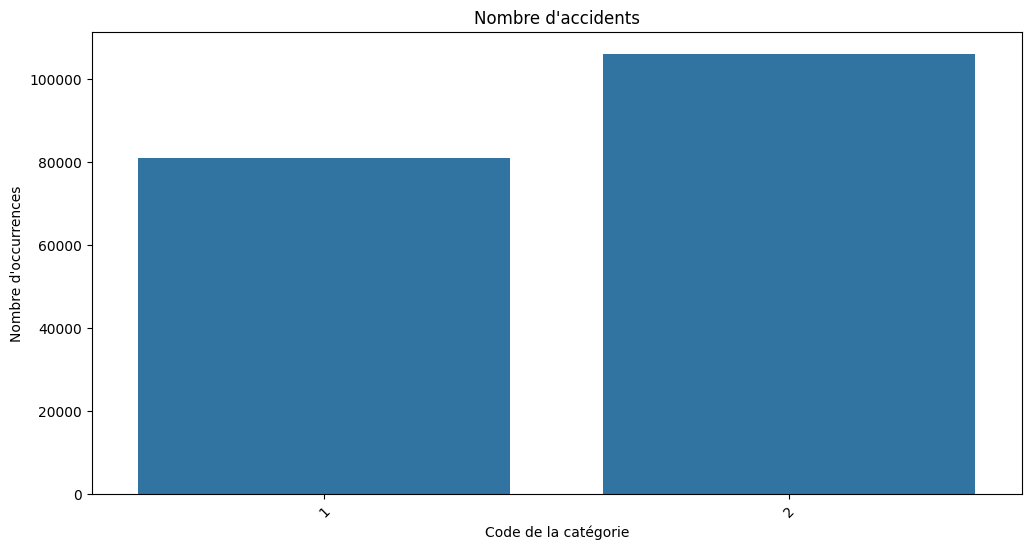

In [1098]:
import matplotlib.pyplot as plt
import seaborn as sns

# On définit la taille du graphique pour que ce soit lisible
plt.figure(figsize=(12, 6))

col = 'agg'

# On crée le graphique de comptage
# order=df['catv'].value_counts().index permet de trier du plus fréquent au moins fréquent
sns.countplot(data=df, x=col)

# On ajoute des titres et des labels
plt.title("Nombre d'accidents")
plt.xlabel("Code de la catégorie")
plt.ylabel("Nombre d'occurrences")

# Si tu as beaucoup de catégories, on incline les labels pour éviter qu'ils se chevauchent
plt.xticks(rotation=45)

plt.show()

# **Normalisation**

In [1099]:
colonnes_num = ['age', 'heure', 'mois']
scaler = StandardScaler()
df[colonnes_num] = scaler.fit_transform(df[colonnes_num])
df.describe()

,place,catu,sexe,trajet,locp,catv,mois,obs,obsm,choc,...,circ,prof,plan,surf,infra,situ,grav,heure,age,is_protected
count,186772.000000,186772.000000,186772.000000,186772.000000,186772.000000,186772.000000,1.867720e+05,186772.000000,186772.000000,186772.000000,...,186772.000000,186772.000000,186772.000000,186772.000000,186772.000000,186772.000000,186772.000000,1.867720e+05,1.867720e+05,186772.000000
mean,1.697546,1.270838,1.315208,3.199313,-0.388816,3.518498,2.373903e-17,0.753373,1.798840,2.446009,...,1.870173,1.230709,1.269419,1.202959,0.756918,1.346481,2.537286,-9.936916e-17,8.690997e-17,0.840479
std,1.900790,0.530003,0.464600,2.751241,0.981996,1.057495,1.000003e+00,2.696111,1.185029,2.415091,...,0.913075,0.544239,0.650741,0.437208,2.126586,1.233176,1.391946,1.000003e+00,1.000003e+00,0.366162
min,1.000000,1.000000,1.000000,0.000000,-1.000000,1.000000,-1.803514e+00,0.000000,-1.000000,0.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,-2.682828e+00,-2.078691e+00,0.000000
25%,1.000000,1.000000,1.000000,0.000000,-1.000000,4.000000,-8.882480e-01,0.000000,2.000000,1.000000,...,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,-7.466114e-01,-8.095653e-01,1.000000
50%,1.000000,1.000000,1.000000,4.000000,-1.000000,4.000000,2.701778e-02,0.000000,2.000000,1.000000,...,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,3.000000,2.214967e-01,-2.025921e-01,1.000000
75%,1.000000,1.000000,2.000000,5.000000,0.000000,4.000000,9.422836e-01,0.000000,2.000000,4.000000,...,2.000000,1.000000,1.000000,1.000000,0.000000,1.000000,4.000000,8.023616e-01,6.802779e-01,1.000000
max,10.000000,3.000000,2.000000,9.000000,9.000000,6.000000,1.552461e+00,17.000000,9.000000,9.000000,...,4.000000,4.000000,4.000000,3.000000,9.000000,8.000000,4.000000,1.770470e+00,3.935861e+00,1.000000


# **Séparation**

In [1100]:
#séparation des données et des labels
labels = df['grav']
labels = labels - 1
df = df.drop(columns=["grav"])

# **Dummies**

In [1101]:
df = pd.get_dummies(df, columns=['place', 'catu', 'sexe', 'trajet', 'locp',
                                 'catv', 'obs', 'obsm', 'choc', 'manv','lum', 'agg', 'int', 'atm', 'col',
                                 'catr', 'circ', 'prof','plan', 'surf', 'infra', 'situ'])
print(len(df.columns))

160


# **Variance**

In [1102]:
variances = df.var(numeric_only=True)
print(variances.sort_values())

locp_7     0.000059
atm_-1     0.000059
situ_-1    0.000128
surf_-1    0.000177
prof_-1    0.000187
             ...   
locp_0     0.245658
locp_-1    0.249403
mois       1.000005
heure      1.000005
age        1.000005
Length: 160, dtype: float64


# **Création du modèle, entraînement et résultats**

In [1103]:
#création des jeux d'entraînement et de test
x_train, x_test, y_train, y_test = train_test_split(df, labels, test_size=0.25, train_size=0.75)

Lancement du test comparatif...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


lbfgs | C=0.01 | Iter=50 -> Acc: 0.4389 | Loss: 1.1737
lbfgs | C=0.01 | Iter=200 -> Acc: 0.4388 | Loss: 1.1736
lbfgs | C=0.01 | Iter=1000 -> Acc: 0.4388 | Loss: 1.1736


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


lbfgs | C=1 | Iter=50 -> Acc: 0.4386 | Loss: 1.1738
lbfgs | C=1 | Iter=200 -> Acc: 0.4388 | Loss: 1.1738
lbfgs | C=1 | Iter=1000 -> Acc: 0.4388 | Loss: 1.1738


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


lbfgs | C=10 | Iter=50 -> Acc: 0.4385 | Loss: 1.1738
lbfgs | C=10 | Iter=200 -> Acc: 0.4387 | Loss: 1.1737
lbfgs | C=10 | Iter=1000 -> Acc: 0.4387 | Loss: 1.1737
newton-cg | C=0.01 | Iter=50 -> Acc: 0.4389 | Loss: 1.1737
newton-cg | C=0.01 | Iter=200 -> Acc: 0.4389 | Loss: 1.1737
newton-cg | C=0.01 | Iter=1000 -> Acc: 0.4389 | Loss: 1.1737
newton-cg | C=1 | Iter=50 -> Acc: 0.4389 | Loss: 1.1738
newton-cg | C=1 | Iter=200 -> Acc: 0.4389 | Loss: 1.1738
newton-cg | C=1 | Iter=1000 -> Acc: 0.4389 | Loss: 1.1738
newton-cg | C=10 | Iter=50 -> Acc: 0.4389 | Loss: 1.1738
newton-cg | C=10 | Iter=200 -> Acc: 0.4389 | Loss: 1.1738
newton-cg | C=10 | Iter=1000 -> Acc: 0.4389 | Loss: 1.1738


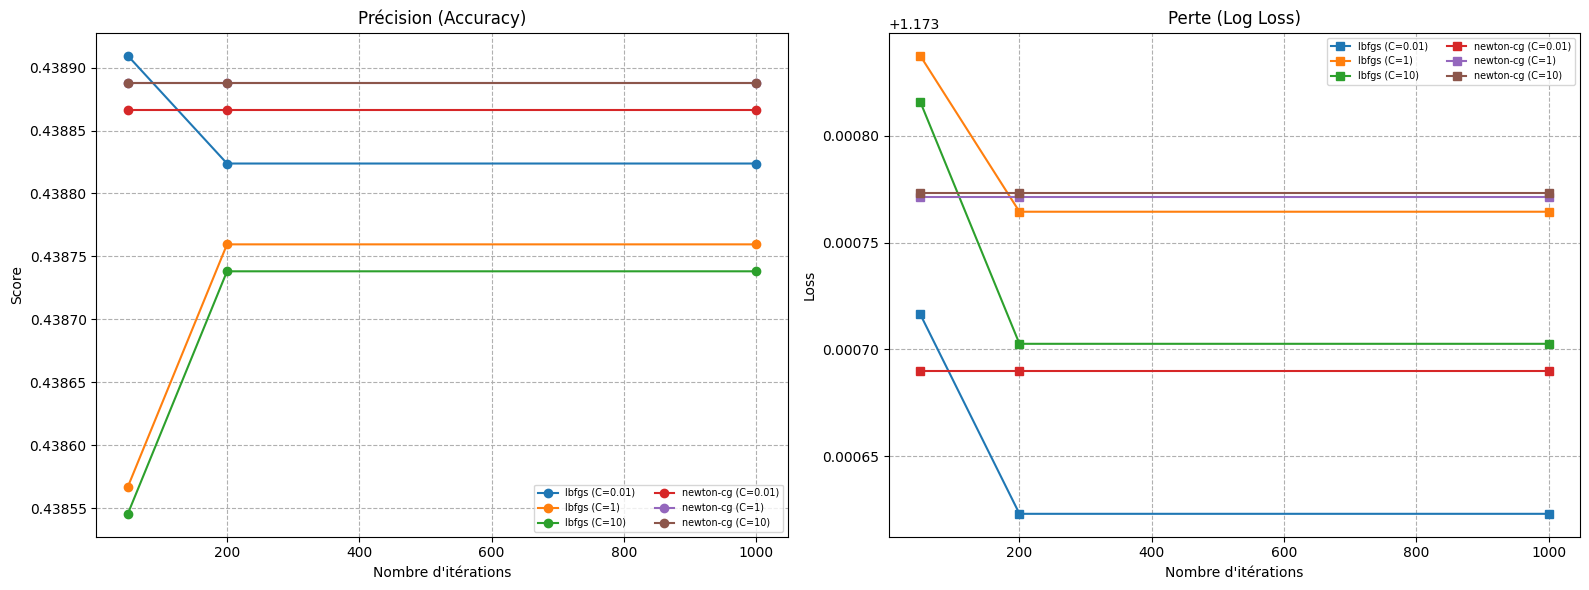

In [1104]:
# 2. Mise à l'échelle (Standardisation) - Crucial pour la Régression Logistique
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# 3. Paramètres à tester
max_iters = [50, 200, 1000]
c_values = [0.01, 1, 10]
solvers = ['lbfgs', 'newton-cg']

results = []

print("Lancement du test comparatif...")

# 4. Triple boucle pour tester les combinaisons
for s in solvers:
    for c in c_values:
        acc_list = []
        loss_list = []

        for m_iter in max_iters:
            # On définit le modèle avec les paramètres de la boucle
            model = LogisticRegression(
                max_iter=m_iter,
                C=c,
                solver=s,
                class_weight='balanced',
                random_state=42
            )

            # Entraînement sur les données scalées
            model.fit(x_train_scaled, y_train)

            # Calcul des scores sur le test
            acc = model.score(x_test_scaled, y_test)
            probs = model.predict_proba(x_test_scaled)
            loss = log_loss(y_test, probs)

            acc_list.append(acc)
            loss_list.append(loss)

            print(f"{s} | C={c} | Iter={m_iter} -> Acc: {acc:.4f} | Loss: {loss:.4f}")

        # On stocke pour le graphique
        results.append({
            'label': f"{s} (C={c})",
            'acc': acc_list,
            'loss': loss_list
        })

# 5. Affichage des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(max_iters, res['acc'], marker='o', label=res['label'])
    ax2.plot(max_iters, res['loss'], marker='s', label=res['label'])

# Graphique de gauche : Accuracy
ax1.set_title("Précision (Accuracy)")
ax1.set_xlabel("Nombre d'itérations")
ax1.set_ylabel("Score")
ax1.legend(fontsize='x-small', ncol=2)
ax1.grid(True, linestyle='--')

# Graphique de droite : Loss
ax2.set_title("Perte (Log Loss)")
ax2.set_xlabel("Nombre d'itérations")
ax2.set_ylabel("Loss")
ax2.legend(fontsize='x-small', ncol=2)
ax2.grid(True, linestyle='--')

plt.tight_layout()
plt.show()

In [1]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import log_loss, accuracy_score

# 1. Définition des listes de paramètres à tester
depths = [5, 10, 20, 50, 100]
min_samples = [10, 50, 100, 1000, 1000]  # Plus c'est haut, plus le modèle est "prudent"
criteria = ['gini', 'entropy'] # Les deux méthodes de calcul mathématique

results = []

# 2. Boucle de test (Grid Search manuel)
for crit in criteria:
    for ms in min_samples:
        acc_list = []
        loss_list = []

        for d in depths:
            model = DecisionTreeClassifier(
                criterion=crit,
                max_depth=d,
                min_samples_split=ms,
                class_weight='balanced',
                random_state=42
            )
            model.fit(x_train, y_train)

            # Calcul des métriques
            y_prob = model.predict_proba(x_test)
            y_pred = model.predict(x_test)

            loss = log_loss(y_test, y_prob)
            accuracy = accuracy_score(y_test, y_pred)

            acc_list.append(accuracy)
            loss_list.append(loss)
            print(f"Test -> Profondeur: {d} | Samples: {ms} | Score: {accuracy:.2%} | Loss: {loss:.2}")

        # On stocke les résultats pour le graphique
        results.append({
            'label': f"{crit} / split={ms}",
            'acc': acc_list,
            'loss': loss_list
        })

# 3. Affichage des graphiques
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for res in results:
    ax1.plot(depths, res['acc'], marker='o', label=res['label'])
    ax2.plot(depths, res['loss'], marker='s', label=res['label'])

# Configuration Graphique 1 : Accuracy
ax1.set_title("Évolution de l'Accuracy (Plus haut = mieux)")
ax1.set_xlabel("Profondeur (max_depth)")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True)

# Configuration Graphique 2 : Loss
ax2.set_title("Évolution de la Log Loss (Plus bas = mieux)")
ax2.set_xlabel("Profondeur (max_depth)")
ax2.set_ylabel("Loss")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

On voit que les valeurs commencent à stagner autour d'une profondeur de 50 \
On constate qu'augmenter le nombre de min_samples ne fait pas tout, car la loss est très faible, mais l'accuracy aussi

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, log_loss

nb_arbres = [10, 50, 100, 200]
profondeurs = [10, 20, 100]
stats_finales = []

for d in profondeurs:
    acc_par_step = []
    loss_par_step = []

    for n in nb_arbres:
        # On lance la machine
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=d,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        )

        rf.fit(x_train, y_train)

        preds = rf.predict(x_test)
        probs = rf.predict_proba(x_test)

        loss = log_loss(y_test, probs)
        accuracy = accuracy_score(y_test, preds)

        label_d = d if d is not None else "Max"
        print(f"Test -> Profondeur: {label_d} | Arbres: {n} | Score: {accuracy:.2%} | Loss: {loss:.4}")

        acc_par_step.append(accuracy)
        loss_par_step.append(loss)

    stats_finales.append({'depth': d, 'acc': acc_par_step, 'loss': loss_par_step})


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for s in stats_finales:
    nom = f"Profondeur {s['depth']}"
    ax1.plot(nb_arbres, s['acc'], '-o', label=nom)
    ax2.plot(nb_arbres, s['loss'], '-s', label=nom)

ax1.set_title("Précision (Accuracy)")
ax1.legend()
ax2.set_title("Erreur (Log Loss)")
ax2.legend()
plt.show()

Test -> Profondeur: 10 | Arbres: 10 | Score: 46.40% | Loss: 1.161
Test -> Profondeur: 10 | Arbres: 50 | Score: 47.66% | Loss: 1.151
Test -> Profondeur: 10 | Arbres: 100 | Score: 47.54% | Loss: 1.151
Test -> Profondeur: 10 | Arbres: 200 | Score: 47.56% | Loss: 1.152
Test -> Profondeur: 20 | Arbres: 10 | Score: 55.85% | Loss: 1.003
Test -> Profondeur: 20 | Arbres: 50 | Score: 59.12% | Loss: 0.9322
Test -> Profondeur: 20 | Arbres: 100 | Score: 59.41% | Loss: 0.9293


On voit ici que les loss et accuracy stagnent à partir d'une profondeur de 100.
On remarque aussi que le nombre d'arbres utilisés améliore légèrement le résultat de nos tests

In [1107]:
#Notre modèle nul à chier
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(x_train.shape[1],)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(50, 'relu'),
    tf.keras.layers.Dense(40, 'relu'),
    tf.keras.layers.Dense(30, 'relu'),
    tf.keras.layers.Dense(20, 'relu'),
    tf.keras.layers.Dense(10, 'relu'),
    tf.keras.layers.Dense(4, 'softmax'),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)
model.summary()
history = model.fit(x_train, y_train, epochs = 50, validation_data = (x_test, y_test))
model.evaluate(x_test, y_test, verbose=2)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 50)             │         8,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 40)             │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30)             │         1,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,194 (47.63 KB)

 Trainable params: 12,194 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.5083 - loss: 0.9922 - val_accuracy: 0.5419 - val_loss: 0.9409
Epoch 2/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5496 - loss: 0.9350 - val_accuracy: 0.5544 - val_loss: 0.9271
Epoch 3/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.5609 - loss: 0.9183 - val_accuracy: 0.5464 - val_loss: 0.9329
Epoch 4/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5643 - loss: 0.9116 - val_accuracy: 0.5583 - val_loss: 0.9201
Epoch 5/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5682 - loss: 0.9019 - val_accuracy: 0.5559 - val_loss: 0.9284
Epoch 6/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5727 - loss: 0.9021 - val_accuracy: 0.5567 - val_loss: 0.9246
Epoch 7/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5740 - loss: 0.8976 - val_accuracy: 0.5608 - val_loss: 0.9188
Epoch 8/50
4378/4378 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.5785 - loss: 0

[0.9435528516769409, 0.560340940952301]

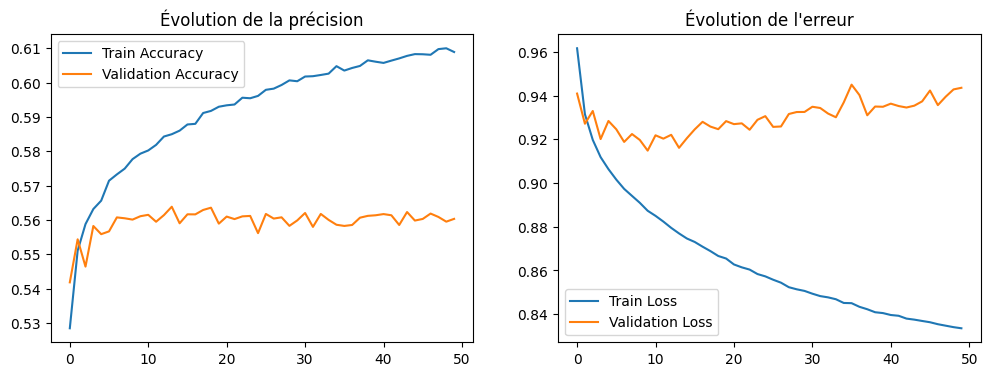

In [1108]:
# Affichage de la précision (Accuracy)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Évolution de la précision')
plt.legend()

# Affichage de l'erreur (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Évolution de l\'erreur')
plt.legend()

plt.show()

### Avec regroupements (160 colonnes) :

RandomForestClassifier (Profondeur 10-Max, Nombre d'arbres 10-200) : [, 0.46-0.63] \
DecisionTreeClassifier (Profondeur 5-100, min_samples 10-1000) :  \
Réseau de neurones : [0.9436, 0.5603] \

Avec nos colonnes et optimisation actuelles, tous les modèles finissent par faire de l'overfitting (haute accuracy / faible loss en entraînement, accuracy moyenne / loss moyenne en test)